In [2]:
%load_ext memory_profiler
import os, gc
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
import matplotlib.pyplot as plt

import numpy as np
from memory_profiler import memory_usage

In [3]:
def simple_cov(X):
    return X @ X.T

def simple_scale(X, alpha=10):
    return alpha * X

def peak_mem_increment(func, *args, interval=0.05, **kwargs):
    # Track process memory over time while func runs; return (peak - baseline) MiB
    baseline = memory_usage(max_iterations=1)[0]
    mem_series = memory_usage((func, args, kwargs), interval=interval)
    return max(mem_series) - baseline

In [7]:
ns = [10 ,20, 50, 100, 200,500, 800, 1000, 1200, 1500, 2000, 5000,10000,15000,20000,30000]   # adjust as your RAM allows
results2 = []
results1 = []

for n in ns:
    X = np.random.randn(n, n).astype(np.float64)
    inc = peak_mem_increment(simple_cov, X, interval=0.05)
    results2.append(inc)
    del X; gc.collect()

    X = np.random.randn(n, n).astype(np.float64)
    inc = peak_mem_increment(simple_scale, X, interval=0.05)
    results1.append(inc)
    del X; gc.collect()

#for n, inc in zip(ns,results):
#    print(f"n={n:4d} -> peak ΔMem ≈ {inc:.2f} MiB")

TypeError: list indices must be integers or slices, not tuple

In [1]:
plt.loglog(ns,results2)
plt.loglog(ns,results1)

NameError: name 'plt' is not defined

NameError: name 'd' is not defined

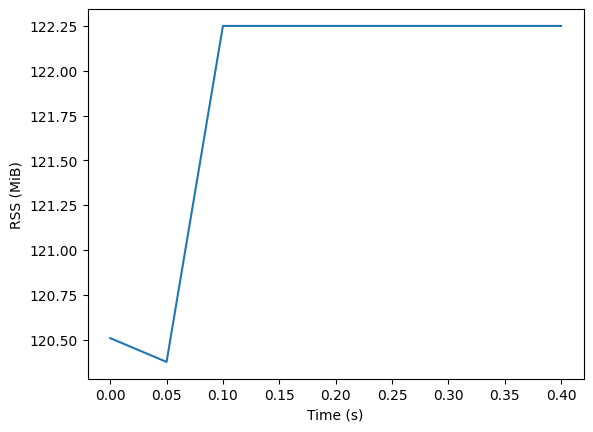

In [4]:
import matplotlib.pyplot as plt
import numpy as np, gc

n = 500
X = np.random.randn(n, n)
interval = 0.05
mem = memory_usage((simple_cov, (X,), {}), interval=interval)
t = np.arange(len(mem)) * interval

plt.plot(t, mem)
plt.xlabel("Time (s)")
plt.ylabel("RSS (MiB)")
plt.title(f"Memory over time (n={n}, d={d})")
plt.show()
del X; gc.collect()